In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm


In [27]:
# Download data
asx = yf.download("^AXJO", start="2000-01-01")["Close"].squeeze()
tsx = yf.download("^GSPTSE", start="2000-01-01")["Close"].squeeze()
audusd = yf.download("AUDUSD=X", start="2000-01-01")["Close"].squeeze()
cadusd = yf.download("CADUSD=X", start="2000-01-01")["Close"].squeeze()

print(asx.shape, tsx.shape)
print(asx.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(6647,) (6609,)
Date
2026-04-20    8953.299805
2026-04-21    8949.400391
2026-04-22    8843.599609
2026-04-23    8793.400391
2026-04-24    8786.500000
Name: ^AXJO, dtype: float64


In [28]:
# Combine and align on common dates
df = pd.DataFrame({
    'asx': asx,
    'tsx': tsx,
    'audusd': audusd,
    'cadusd': cadusd
}).dropna()

# Convert indices to USD
df['asx_usd'] = df['asx'] * df['audusd']
df['tsx_usd'] = df['tsx'] * df['cadusd']

print(df.shape)
print(df.head())
print(df.tail())

(4910, 6)
                    asx           tsx    audusd    cadusd      asx_usd  \
Date                                                                     
2006-05-16  5217.399902  11829.400391  0.767106  0.903342  4002.301240   
2006-05-17  5217.500000  11640.599609  0.759417  0.896781  3962.256940   
2006-05-18  5119.299805  11540.000000  0.764000  0.893176  3911.146569   
2006-05-19  5100.899902  11545.799805  0.757174  0.894935  3862.269772   
2006-05-23  5013.799805  11539.900391  0.750976  0.889047  3765.244947   

                 tsx_usd  
Date                      
2006-05-16  10685.998540  
2006-05-17  10439.063326  
2006-05-18  10307.251949  
2006-05-19  10332.736356  
2006-05-23  10259.513442  
                    asx           tsx    audusd    cadusd      asx_usd  \
Date                                                                     
2026-04-20  8953.299805  34360.000000  0.713500  0.729661  6388.178015   
2026-04-21  8949.400391  33808.300781  0.717420  0.732923  6

In [29]:
# Test for cointegration
score, pvalue, _ = coint(df['asx_usd'], df['tsx_usd'])
print(f"Cointegration p-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("✓ Cointegrated at 95% confidence — spread mean reversion is statistically justified")
else:
    print("✗ No cointegration found — results should be interpreted with caution")

Cointegration p-value: 0.0271
✓ Cointegrated at 95% confidence — spread mean reversion is statistically justified


In [37]:
# 1. ADF on individual series - expecting non-stationary (p > 0.05)
adf_asx = adfuller(df['asx_usd'])
adf_tsx = adfuller(df['tsx_usd'])

print("=== ADF Tests on Price Series (expecting p > 0.05) ===")
print(f"ASX USD p-value: {adf_asx[1]:.4f} {'✓ non-stationary' if adf_asx[1] > 0.05 else '✗ stationary'}")
print(f"TSX USD p-value: {adf_tsx[1]:.4f} {'✓ non-stationary' if adf_tsx[1] > 0.05 else '✗ stationary'}")

# 2. ADF on spread - expecting stationary (p < 0.05)
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

X = sm.add_constant(df['tsx_usd'])
model = sm.OLS(df['asx_usd'], X).fit()
hedge_ratio = model.params['tsx_usd']
df['spread'] = df['asx_usd'] - hedge_ratio * df['tsx_usd']

adf_spread = adfuller(df['spread'])
print(f"\n=== ADF Test on Spread (expecting p < 0.05) ===")
print(f"Spread p-value: {adf_spread[1]:.4f} {'✓ stationary' if adf_spread[1] < 0.05 else '✗ non-stationary'}")

# 3. Variance ratio test
def variance_ratio(series, lag=2):
    var1 = series.diff().var()
    vark = series.diff(lag).var() / lag
    return vark / var1

# Hurst exponent
def hurst(series, max_lag=100):
    lags = range(2, max_lag)
    tau = [np.std(series.diff(lag).dropna()) for lag in lags]
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0]

h = hurst(df['spread'])
print(f"=== Hurst Exponent ===")
print(f"Hurst: {h:.4f}")
if h < 0.5:
    print("✓ Mean reverting (H < 0.5)")
elif h == 0.5:
    print("~ Random walk (H = 0.5)")
else:
    print("✗ Trending (H > 0.5)")

vr = variance_ratio(df['spread'])
print(f"\n=== Variance Ratio Test (lag=2) ===")
print(f"Variance ratio: {vr:.4f} {'✓ mean reverting' if vr < 1 else '✗ no mean reversion'}")

spread_lag = df['spread'].shift(1).dropna()
spread_diff = df['spread'].diff().dropna()
model_hl = sm.OLS(spread_diff, sm.add_constant(spread_lag)).fit()
half_life = -np.log(2) / model_hl.params.iloc[1]
print(f"\n=== Half-Life of Mean Reversion ===")
print(f"Half-life: {half_life:.1f} days")

=== ADF Tests on Price Series (expecting p > 0.05) ===
ASX USD p-value: 0.0497 ✗ stationary
TSX USD p-value: 0.9491 ✓ non-stationary

=== ADF Test on Spread (expecting p < 0.05) ===
Spread p-value: 0.0064 ✓ stationary
=== Hurst Exponent ===
Hurst: 0.4378
✓ Mean reverting (H < 0.5)

=== Variance Ratio Test (lag=2) ===
Variance ratio: 0.7568 ✓ mean reverting

=== Half-Life of Mean Reversion ===
Half-life: 63.2 days


Sharpe Ratio:   0.935
CAGR:           13.11%
Max Drawdown:   -60.24%
Calmar Ratio:   0.218
Total Return:   977.68%


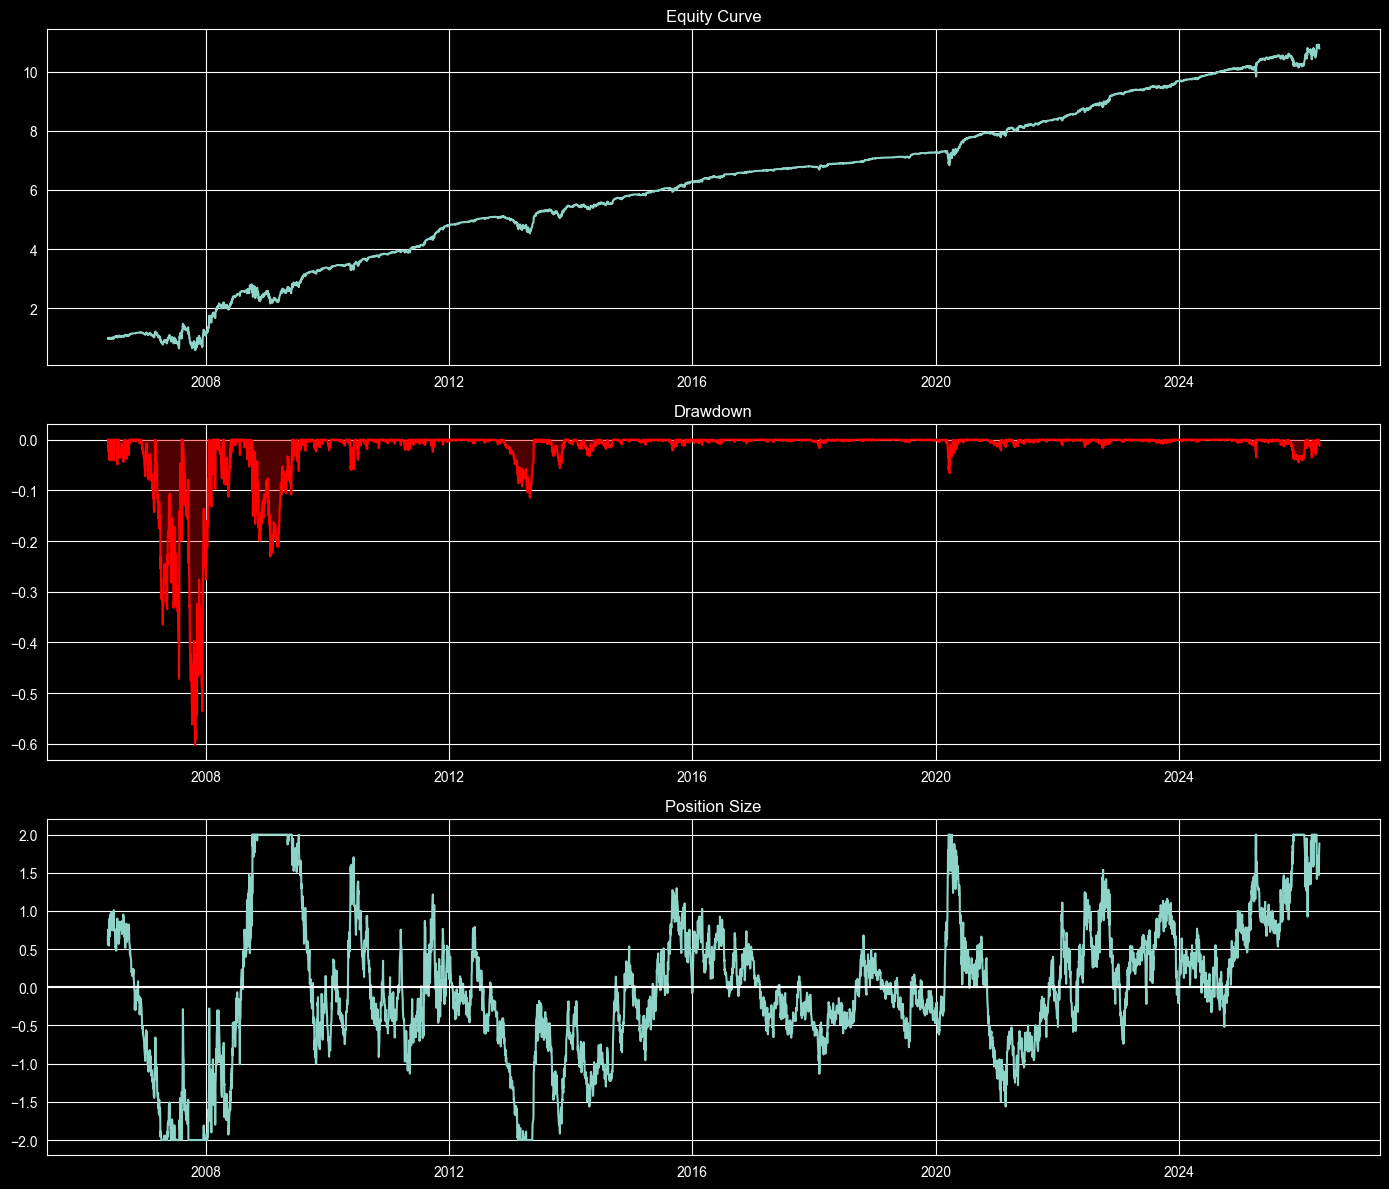

In [44]:
df['position'] = (-df['zscore']).clip(-2, 2)

# Dollar PnL on spread
df['spread_pnl'] = df['position'].shift(1) * df['spread'].diff()

# Normalise by initial spread value to get a return-like series
df['strategy_return'] = df['spread_pnl'] / df['spread'].iloc[0]

df = df.dropna()

equity = 1 + df['strategy_return'].cumsum()  # arithmetic, not geometric
returns = df['strategy_return']

sharpe = np.sqrt(252) * returns.mean() / returns.std()
roll_max = equity.cummax()
drawdown = (equity - roll_max) / roll_max
max_dd = drawdown.min()
n_years = len(df) / 252
cagr = (equity.iloc[-1] / equity.iloc[0]) ** (1/n_years) - 1
calmar = cagr / abs(max_dd)

print(f"Sharpe Ratio:   {sharpe:.3f}")
print(f"CAGR:           {cagr:.2%}")
print(f"Max Drawdown:   {max_dd:.2%}")
print(f"Calmar Ratio:   {calmar:.3f}")
print(f"Total Return:   {equity.iloc[-1]-1:.2%}")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
axes[0].plot(df.index, equity)
axes[0].set_title('Equity Curve')
axes[1].plot(df.index, drawdown, color='red')
axes[1].fill_between(df.index, drawdown, 0, alpha=0.3, color='red')
axes[1].set_title('Drawdown')
axes[2].plot(df.index, df['position'])
axes[2].axhline(0, color='white', linestyle='-')
axes[2].set_title('Position Size')
plt.tight_layout()
plt.show()